# Malaysia Semiconductor Shortage: Trade and Manufacturing Impact (2021–2026)

## The Question

How did the 2021–2023 global semiconductor shortage affect Malaysia's electrical & electronics (E&E) export performance, and what does the recovery pattern reveal about supply chain resilience for businesses operating here?

This notebook tests a specific hypothesis: that manufacturing output (a production constraint) would show the disruption first, while trade figures (finished goods actually crossing the border) would lag behind due to existing inventory buffers and shipping timelines. Two datasets are compared — Section 7 trade data (a broad proxy including but not limited to electronics) and Division 26 manufacturing output (a precise match for electronics specifically). The analysis window extends through mid-2026, beyond the shortage itself, to see whether any disruption left a lasting mark or whether the market fully normalized.

## The Answer

Neither Section 7 trade data nor Division 26 manufacturing output shows a clean, isolated "shortage hits, then recovers" pattern. Both series are continuously volatile across the entire 2021–2026 window, and the dip observed in early 2023 — initially suspected to be the shortage's mark — turns out to be indistinguishable from the sector's normal cyclical swings once compared against a longer baseline; troughs of similar or greater depth recur regularly through 2024–2026 with no connection to the shortage.

More strikingly, both series show substantial growth well beyond pre-shortage levels: Section 7 trade values roughly doubled from 2021 to 2026, and Division 26 manufacturing output rose from a range of ~120–170 in 2021 to consistently above 190 by 2025–2026. At this level of data granularity, there is no visible evidence of lasting damage from the 2021–2023 global semiconductor shortage to Malaysia's E&E trade or manufacturing sector — both not only recovered but grew substantially past their pre-shortage baseline within a few years.

This is a different, and arguably more useful, finding than the "production dips before trade, then both recover" hypothesis this notebook set out to test. That hypothesis assumed an isolable disruption event to measure a lag around — but the data shows continuous volatility with no such isolable event, making the original question unanswerable in the way it was framed. The real finding is about resilience at the aggregate level, not about the shortage's specific mechanics.

## Trade impact: Section 7 exports, 2021–2026

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

trade = pd.read_csv('../data/raw/trade_sitc_1d.csv')
trade_section7 = trade[(trade['section'] == '7') & (trade['date'] >= '2021-01-01') & (trade['date'] <= '2026-06-01')].copy()
trade_section7['date'] = pd.to_datetime(trade_section7['date'])
trade_section7.head()

,date,section,exports,imports
2796,2021-01-01,7,4.173121e+10,3.122565e+10
2797,2021-02-01,7,3.624811e+10,2.893345e+10
2798,2021-03-01,7,4.590081e+10,3.350068e+10
2799,2021-04-01,7,4.281451e+10,3.367561e+10
2800,2021-05-01,7,3.658587e+10,3.265689e+10


In [2]:
# House chart style: consistent palette, clean chrome, and a source-footnote helper
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#4a3aa7', '#e34948']
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#e1e0d9', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)


## Visualizing Section 7 trade through and beyond the shortage window

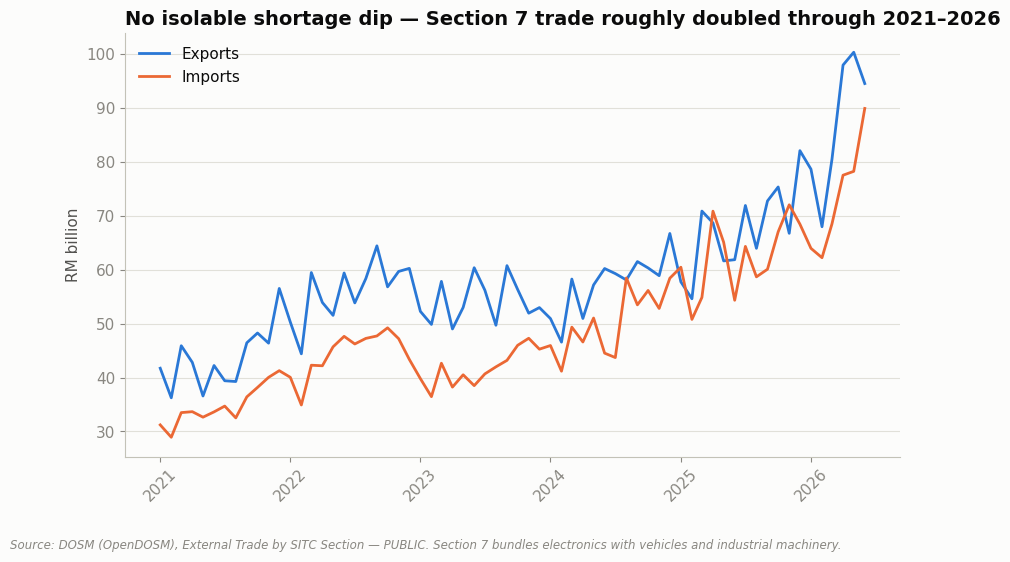

In [3]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(trade_section7['date'], trade_section7['exports'] / 1e9, linewidth=2,
        color=PALETTE[0], label='Exports')
ax.plot(trade_section7['date'], trade_section7['imports'] / 1e9, linewidth=2,
        color=PALETTE[1], label='Imports')

ax.set_title('No isolable shortage dip — Section 7 trade roughly doubled through 2021–2026', loc='left')
ax.set_ylabel('RM billion')
ax.set_xlabel('')
ax.legend()
plt.xticks(rotation=45)

add_source(ax.figure, 'Source: DOSM (OpenDOSM), External Trade by SITC Section — PUBLIC. '
                       'Section 7 bundles electronics with vehicles and industrial machinery.')
plt.show()


## Manufacturing output impact: Division 26 (computer, electronic and optical products), 2021–2026

Unlike Section 7's trade proxy, Division 26 isolates electronics manufacturing specifically. This is the more precise test of whether the chip shortage left a visible mark.

In [4]:
ipi = pd.read_csv('../data/raw/ipi_2d.csv')

print(ipi['division'].dtype)
print(ipi['division'].unique())

int64
[ 6 10 11 12 13 14 15 16 17 18 31 19 20 21 22 23 24 25 26 27 28 29 30 32
 33 35]


In [5]:
# division is stored as int64, not string — filter accordingly
ipi_div26 = ipi[
    (ipi['series'] == 'abs') &
    (ipi['division'] == 26) &
    (ipi['date'] >= '2021-01-01') &
    (ipi['date'] <= '2026-06-01')
].copy()
ipi_div26['date'] = pd.to_datetime(ipi_div26['date'])
ipi_div26.head()

,series,date,division,index
7236,abs,2021-01-01,26,142.175
7237,abs,2021-02-01,26,121.845
7238,abs,2021-03-01,26,130.606
7239,abs,2021-04-01,26,134.257
7240,abs,2021-05-01,26,134.903


## Visualizing Division 26 manufacturing output through and beyond the shortage window

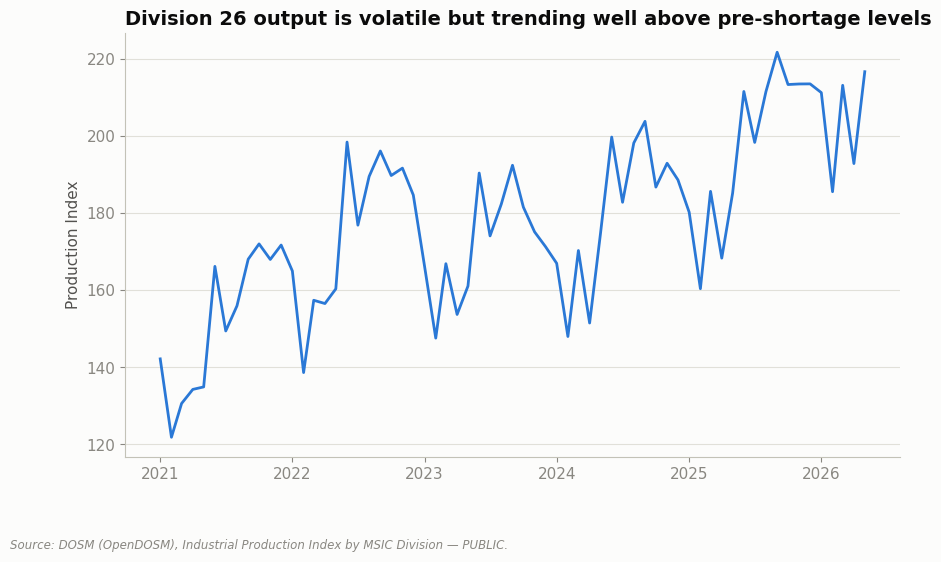

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(ipi_div26['date'], ipi_div26['index'], linewidth=2, color=PALETTE[0])

ax.set_title('Division 26 output is volatile but trending well above pre-shortage levels', loc='left')
ax.set_ylabel('Production Index')
ax.set_xlabel('')

add_source(ax.figure, 'Source: DOSM (OpenDOSM), Industrial Production Index by MSIC Division — PUBLIC.')
plt.show()


## Strategic Recommendation

- **Businesses should not assume aggregate national trade or production data will reveal supply chain disruptions clearly**, even significant ones like the 2021–2023 chip shortage. At this level of granularity, sector-wide volatility can fully mask a real disruption's signature — a business genuinely affected by a shortage would need firm-level or product-level data to see it, not the national aggregates used here.
- **Malaysia's E&E sector shows strong aggregate resilience** — both trade and manufacturing output grew substantially past pre-shortage levels within a few years. This is a reasonable basis for confidence in the sector's ability to absorb future global supply shocks, though it says nothing about which specific firms struggled or thrived during the disruption itself.
- **For businesses evaluating supply chain risk in Malaysia's electronics sector, the more useful question may not be "did the last shortage cause lasting damage" (it apparently didn't, at this level) but "how quickly can the sector re-accelerate after a shock"** — a question this data can't fully answer either, since no clean shortage-only period exists to isolate.

## Confidence & Caveats

- **Section 7 is a broad proxy, not an isolated electronics measure.** It bundles E&E with other machinery and transport equipment; a real shortage-specific trade signal could be present but diluted by unrelated growth in other goods within the same category.
- **Division 26 is a genuine, specific match for electronics manufacturing**, giving this notebook's manufacturing-side conclusions more confidence than its trade-side conclusions.
- **The original hypothesis (manufacturing leads, trade lags) could not be properly tested**, because neither series shows a single, isolable dip-and-recovery event attributable specifically to the shortage — both show continuous volatility throughout the whole window, shortage or not.
- **This analysis cannot distinguish firm-level impact from sector-level aggregates.** Individual companies may have experienced serious disruption even while the sector-wide numbers show no lasting mark — aggregate resilience does not mean every business within the sector was equally resilient.
- **No baseline pre-pandemic comparison (e.g., 2018–2019) was included**, which would help establish what "normal" volatility looks like for this sector independent of any shortage or pandemic effects — a natural next step if this analysis were extended.